# Week 4: Transfer Learning, BERT (Homework)

## Question Search Engine

Embeddings are a good source of information for solving various tasks. For example, we can classify texts or find similar documents using their representations. We already know about word2vec, GloVe and fasttext, but they don't use context information from given text (only from contexts of source data).

For today we will use full power of context-aware embeddings to find text duplicates!

__Warning:__ this task assumes you have seen `seminar.ipynb`!

In [2]:
import os
from IPython.display import clear_output

notebook_dir = "/home/balabaevvl/courses/nlp/nlp_course/week04_transfer"  # notebook's dir
os.chdir(notebook_dir)

print("Current dir:", os.getcwd())


Current dir: /home/balabaevvl/courses/nlp/nlp_course/week04_transfer


In [3]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "GPU-fe2d8dfd-06f2-a5c4-a7fd-4a5f23947005"     # 2
# os.environ["CUDA_VISIBLE_DEVICES"] = "GPU-baef952c-6609-aace-3b78-e4e07788d5de"     # 4
# os.environ["CUDA_VISIBLE_DEVICES"] = "GPU-3979d65b-c238-4e9c-0c1c-1aa3f05c56a1"     # 5

import torch
device = torch.device('cuda:0')
# device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [4]:
import shutil, os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"    # problems with progress bar

# from huggingface_hub.constants import HF_HUB_CACHE
# cache = os.path.expanduser(HF_HUB_CACHE)
# for d in os.listdir(cache):
#     if d.startswith("models--distilbert-base-uncased-finetuned-sst-2-english"):
#         shutil.rmtree(os.path.join(cache, d), ignore_errors=True)

# from huggingface_hub import snapshot_download
# local_dir = snapshot_download("distilbert-base-uncased-finetuned-sst-2-english")


In [5]:
# %pip install --upgrade transformers datasets accelerate deepspeed
import torch
import torch.nn as nn
import torch.nn.functional as F
import transformers
import datasets

### Data Preparation

In [6]:
qqp = datasets.load_dataset("SetFit/qqp")
print("\n")
print("Sample[0]:", qqp["train"][0])
print("Sample[3]:", qqp["train"][3])

Repo card metadata block was not found. Setting CardData to empty.




Sample[0]: {'text1': 'How is the life of a math student? Could you describe your own experiences?', 'text2': 'Which level of prepration is enough for the exam jlpt5?', 'label': 0, 'idx': 0, 'label_text': 'not duplicate'}
Sample[3]: {'text1': 'What can one do after MBBS?', 'text2': 'What do i do after my MBBS ?', 'label': 1, 'idx': 3, 'label_text': 'duplicate'}


In [6]:
model_name = "gchhablani/bert-base-cased-finetuned-qqp"
tokenizer = transformers.AutoTokenizer.from_pretrained(model_name)
model = transformers.AutoModelForSequenceClassification.from_pretrained(model_name)

BERT encodes a sentence pair:
[CLS] Sentence A [SEP] Sentence B [SEP]

BERT’s **segment embeddings** are *added* to token and positional embeddings:

$$
E_{\text{input}} = E_{\text{token}} + E_{\text{position}} + E_{\text{segment}}
$$


In [7]:
MAX_LENGTH = 128

def preprocess_function(examples):
    result = tokenizer(
        examples["text1"],
        examples["text2"],
        padding="max_length",
        max_length=MAX_LENGTH,
        truncation=True,
    )

    result["label"] = examples["label"]

    return result

In [8]:
qqp_preprocessed = qqp.map(preprocess_function, batched=True)

In [9]:
print(repr(qqp_preprocessed["train"][0]["input_ids"])[:100], "...")

[101, 1731, 1110, 1103, 1297, 1104, 170, 12523, 2377, 136, 7426, 1128, 5594, 1240, 1319, 5758, 136,  ...


### Evaluation (1 point)

We randomly chose a model trained on QQP - but is it any good?

One way to measure this is with validation accuracy - which is what you will implement next.

Here's the interface to help you do that:

In [10]:
val_set = qqp_preprocessed["validation"]
val_loader = torch.utils.data.DataLoader(
    val_set, batch_size=1, shuffle=False, collate_fn=transformers.default_data_collator
)


In [11]:
for batch in val_loader:
    break
# print("Sample batch:", batch)

with torch.no_grad():
    predicted = model(
        input_ids=batch["input_ids"],
        attention_mask=batch["attention_mask"],
        token_type_ids=batch["token_type_ids"],
    )

print("\nPrediction (probs):", torch.softmax(predicted.logits, dim=1).data.numpy())



Prediction (probs): [[9.99892712e-01 1.07280895e-04]]


**Task 1 (1 point)**

- Measure the validation accuracy of your model. Doing so naively may take several hours. Please make sure you use the following optimizations:
  - Run the model on GPU with no_grad
  - Using batch size larger than 1
  - Use optimize data loader with num_workers > 1
  - (Optional) Use [mixed precision](https://pytorch.org/docs/stable/notes/amp_examples.html)


In [12]:
val_loader = torch.utils.data.DataLoader(
    val_set, 
    batch_size=128, 
    shuffle=False, 
    collate_fn=transformers.default_data_collator,
    # num_workers = min(4, os.cpu_count()),
)

correct = 0
total = 0
accuracies = []

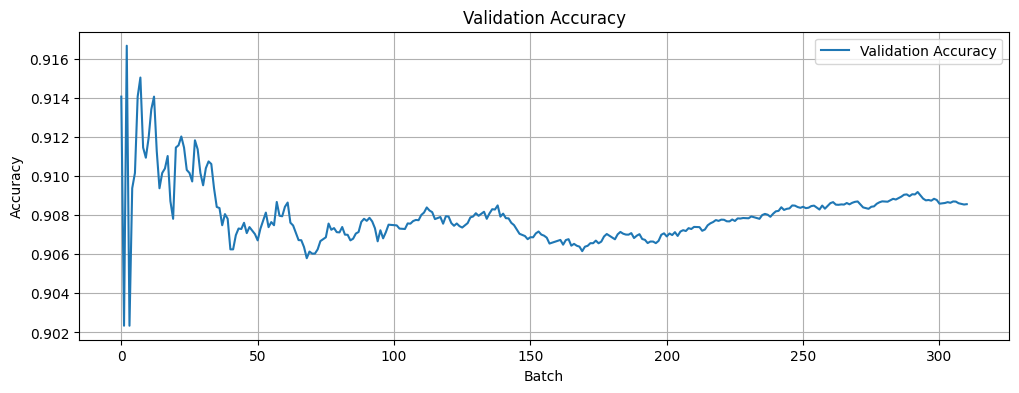

Accuracy: 0.9086


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 316/316 [03:19<00:00,  1.58it/s]


In [13]:
import matplotlib.pyplot as plt
from tqdm import tqdm
%matplotlib inline


@torch.no_grad()
def to_device(batch, device):
    out = {}
    for k, v in batch.items():
        if torch.is_tensor(v):
            out[k] = v.to(device, non_blocking=True)
        else:
            out[k] = v
    return out

model.to(device)    # !
model.eval()

for step, batch in enumerate(tqdm(val_loader)):
    # `val_set` has "label"
    # `batch` has "labels"
    batch = to_device(batch, device)

    with torch.no_grad():
        predicted = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            token_type_ids=batch["token_type_ids"],
        )

    labels = batch["labels"]
    preds = torch.argmax(predicted.logits, dim=-1)
    correct += (preds == labels).sum().item()
    total += labels.size(0)

    accuracy = correct / total
    accuracies.append(accuracy)


    if step % 10 == 0:
        clear_output(True)

        plt.figure(figsize=(12,4))
        plt.plot(accuracies, label='Validation Accuracy')
        plt.xlabel('Batch')
        plt.ylabel('Accuracy')
        plt.title('Validation Accuracy')
        plt.legend()
        plt.grid()
        plt.show()

        print(f"Accuracy: {accuracy:.4f}", flush=True)


In [14]:
assert 0.9 < accuracy < 0.91

### Training (4 points)

For this task, you have two options:

__Option A:__ fine-tune your own model. You are free to choose any model __except for the original BERT.__ We recommend [DeBERTa-v3](https://huggingface.co/microsoft/deberta-v3-base). Better yet, choose the best model based on public benchmarks (e.g. [GLUE](https://gluebenchmark.com/)).

You can write the training code manually or use transformers.Trainer (see [this example](https://github.com/huggingface/transformers/blob/main/examples/pytorch/text-classification)). Please make sure that your model's accuracy is at least __comparable__ with the above example for BERT.


__Option B:__ compare at least 3 pre-finetuned models (in addition to the above BERT model). For each model, report (1) its accuracy, (2) its speed, measured in samples per second in your hardware setup and (3) its size in megabytes. Please take care to compare models in equal setting, e.g. same CPU / GPU. Compile your results into a table and write a short (~half-page on top of a table) report, summarizing your findings.

**Task 2 (4 points)**
- Choose Option A or Option B (only one will be graded)
- Follow all the instructions and restrictions

In [8]:
model_name = "microsoft/deberta-v3-base"

qqp = datasets.load_dataset("SetFit/qqp")

tokenizer = transformers.AutoTokenizer.from_pretrained(model_name)
model = transformers.AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
model.to(device)    # !

clear_output()

In [9]:
def preprocess_function(examples):
    result = tokenizer(
        examples["text1"],
        examples["text2"],
        padding="max_length",
        max_length=MAX_LENGTH,
        truncation=True,
    )

    # apperantly `DataLoader` which turns "label" into "labels"
    # we don't use it, so need to manually do it
    result["labels"] = examples["label"]

    return result


qqp_preprocessed = qqp.map(
    preprocess_function, 
    batched=True, 
)

Map:   0%|          | 0/40430 [00:00<?, ? examples/s]

In [28]:
import numpy as np
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = (preds == labels).mean()
    return {"accuracy": acc}


data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    return_tensors="pt"  # PyTorch tensors
)

training_args = TrainingArguments(
    output_dir="./deberta-qqp",
    eval_strategy="steps",
    eval_steps=500,
    logging_steps=500,
    logging_dir="./logs",
    report_to="none",

    # hypers
    learning_rate=1e-4,
    num_train_epochs=1,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_ratio=0.1,
)


In [29]:
print(qqp_preprocessed["test"]["labels"])
# all -1 -> can't use test as test :) -> we'll use validation

Column([-1, -1, -1, -1, -1])


In [ ]:
train_dataset = qqp_preprocessed["train"]
validation_dataset = qqp_preprocessed["validation"].select(range(3_000))
test_dataset = qqp_preprocessed["validation"].select(range(5000, 25000))


In [31]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset,
    # processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [21]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 

In [23]:
# check test results before training
results = trainer.evaluate(test_dataset)
print(results)

{'eval_loss': 0.6734563708305359, 'eval_model_preparation_time': 0.0423, 'eval_accuracy': 0.6345, 'eval_runtime': 120.7646, 'eval_samples_per_second': 165.611, 'eval_steps_per_second': 10.351}


In [32]:
trainer.train()

Step,Training Loss,Validation Loss,Accuracy
500,0.492100,0.327150,0.858667
1000,0.378900,0.326906,0.861333
1500,0.371800,0.355137,0.841333
2000,0.380800,0.342798,0.849667
2500,0.399900,0.369941,0.842333
3000,0.383000,0.387279,0.839333
3500,0.372300,0.347367,0.855667
4000,0.362600,0.343536,0.856333
4500,0.375500,0.344133,0.854667
5000,0.371800,0.348251,0.859000


TrainOutput(global_step=22741, training_loss=0.32013986536445954, metrics={'train_runtime': 8090.7072, 'train_samples_per_second': 44.971, 'train_steps_per_second': 2.811, 'total_flos': 2.393340547233485e+16, 'train_loss': 0.32013986536445954, 'epoch': 1.0})

In [34]:
results = trainer.evaluate(test_dataset)
print(results)
# eval_accuracy = 0.8976
# ~ 0.9086 of "gchhablani/bert-base-cased-finetuned-qqp"
# if trained on more 1> epochs mb i would get even higher. but it takes soooooooo much time

{'eval_loss': 0.25709643959999084, 'eval_accuracy': 0.89765, 'eval_runtime': 117.2866, 'eval_samples_per_second': 170.522, 'eval_steps_per_second': 10.658, 'epoch': 1.0}


### Finding Duplicates (1 point)

Finally, it is time to use your model to find duplicate questions.
Please implement a function that takes a question and finds top-5 potential duplicates in the training set. For now, it is fine if your function is slow, as long as it yields correct results.

Showcase how your function works with at least 5 examples.

**Task 3 (1 point)**
- Implement function for finding duplicates
- Test it on several examples (at least 5)
- Check suggested duplicates and make a conclusion about model correctness

In [73]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model_path = "deberta-qqp/checkpoint-22741"

model = AutoModelForSequenceClassification.from_pretrained(model_path)
tokenizer = AutoTokenizer.from_pretrained(model_path, return_tensors="pt")

model.to(device)

model.eval()        # for inference

clear_output()

In [ ]:
test_dataset = qqp_preprocessed["test"].select(range(5000))

test_texts = [i["text2"] for i in test_dataset]

examples = [i["text1"] for i in test_dataset.select(range(0, 500, 100))]

for i in examples:
    print(i)


Would the idea of Trump and Putin in bed together scare you, given the geopolitical implications?
What are some of NASA's greatest successes?
How should I prepare for the FE chemical engineering exam?
How can Philippines become a superpower?
What are some good SEO tools for content writing?


In [123]:
import heapq
from typing import Any, Callable

class TopK:
    """
    Maintains the top-k elements by a comparator function `key`.
    Example: TopK(k=5, key=lambda x: x.score)
    """
    def __init__(self, k: int, key: Callable[[Any], float]):
        self.k = k
        self.key = key
        self.heap = []

    def add(self, obj: Any):
        value = self.key(obj)

        if len(self.heap) < self.k:
            heapq.heappush(self.heap, (value, obj))
        else:
            if value > self.heap[0][0]:
                heapq.heapreplace(self.heap, (value, obj))

    def get_topk(self, reverse=True):
        """Return top-k sorted by score (descending by default)."""
        return [obj for _, obj in sorted(self.heap, key=lambda x: x[0], reverse=reverse)]


In [124]:
from dataclasses import dataclass

@dataclass
class SimilarText:
    text: str
    similarity: float

In [125]:
from tqdm import tqdm


for example in examples:
    top5 = TopK(5, lambda x: x.similarity)

    for text in tqdm(test_texts):
        inputs = tokenizer(example, text, padding=True, truncation=True)
        inputs = {k: torch.tensor(inputs[k]).unsqueeze(0) for k in inputs.keys()}
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            out = model(**inputs)

        logits = out.logits[0]
        probs = torch.nn.functional.softmax(logits, dim=-1)
        # pred = torch.argmax(probs, dim=-1).item()

        similarity = float(probs[1])
        top5.add(SimilarText(text, similarity))

    print(f">>>Example:\n{example}\n>>>Similar found:")
    found = top5.get_topk()
    for i, text in enumerate(found):
        print(f"{i}. (Similarity={text.similarity:.3f}) {text.text}")
    print("\n")
    
# looks good, keeping in mind 5000 test texts

  0%|                                                                                                                                                                 | 0/5000 [00:00<?, ?it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [03:11<00:00, 26.14it/s]


>>>Example:
Would the idea of Trump and Putin in bed together scare you, given the geopolitical implications?
>>>Similar found:
0. (Similarity=0.029) Do you think that if Donald Trump were elected President, he would be able to restore relations with Putin and Russia as he said he could, based on the rocky relationship Putin had with Obama and Bush?
1. (Similarity=0.001) Who is scarier to be elected as president, Donald Trump or Hillary Clinton?
2. (Similarity=0.001) Julia’s frogs are 2/5 of the amount of Rimma’s frogs Rimma gives 1/2 of her frogs to Julia what will be the ratio of Julia’s frogs to Rimma’s frogs?
3. (Similarity=0.001) If America went to war with Russia who would win and why?
4. (Similarity=0.001) Why doesn't Quora say when a question is posted needs improvement they don't say why it needs improvement?




100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [03:14<00:00, 25.70it/s]


>>>Example:
What are some of NASA's greatest successes?
>>>Similar found:
0. (Similarity=0.061) If universe and space is expanding? Does that mean anything that occupies space is also expanding?
1. (Similarity=0.050) What are some of NASA's greatest failures?
2. (Similarity=0.042) Why doesn't Quora say when a question is posted needs improvement they don't say why it needs improvement?
3. (Similarity=0.031) Why do people block others? What are the reasons to block someone?
4. (Similarity=0.024) Why do people ask questions on Quora that are easily answered with a Google/Wikipedia search?




...

>>>Example:
How should I prepare for the FE chemical engineering exam?
>>>Similar found:
0. (Similarity=0.043) How do I prepare for physics 12th cbse in 1 month to get good marks?
1. (Similarity=0.039) How can I crack NEET 2017?
2. (Similarity=0.036) What are the best ways to prepare for CAT in the final three months?
3. (Similarity=0.032) How can I prepare for CAT examination while working for 9 hours all weekdays?
4. (Similarity=0.030) How did you prepare for CAT?which books did you refer to?




100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [03:16<00:00, 25.43it/s]


>>>Example:
How can Philippines become a superpower?
>>>Similar found:
0. (Similarity=0.032) What is the exact meaning of 'mother pious lady'? How do you justify the title of the book Mother Pious Lady?
1. (Similarity=0.022) Why doesn't Quora say when a question is posted needs improvement they don't say why it needs improvement?
2. (Similarity=0.014) How does a 3rd world country become a 1st world country?
3. (Similarity=0.011) Why does Quora allow so many questions easily answered by a search engine?
4. (Similarity=0.009) Why do people ask questions on Quora that are easily answered with a Google/Wikipedia search?




100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [03:25<00:00, 24.38it/s]

>>>Example:
What are some good SEO tools for content writing?
>>>Similar found:
0. (Similarity=0.154) Why do people ask Quora questions instead of just searching google?
1. (Similarity=0.154) Why do people ask Quora questions instead of just searching google?
2. (Similarity=0.072) Why do people ask questions on Quora that are easily answered with a Google/Wikipedia search?
3. (Similarity=0.064) How can one create a search engine for his own website?
4. (Similarity=0.052) Why does Quora allow so many questions easily answered by a search engine?




### Bonus: Finding Duplicates Faster (0.5 point)

Try to find a way to run the function faster than just passing over all questions in a loop. For isntance, you can form a short-list of potential candidates using a cheaper method, and then run your tranformer on that short list. If you opted for this solution, please keep both the original implementation and the optimized one - and explain briefly what is the difference there.

**Bonus Task 1 (0.5 point)**
- Speed up your implementation from "Finding Duplicates" part
- Capture both old and new implementation work time
- Describe your approach

In [ ]:
<A whole lot of YOUR CODE HERE>

### Bonus: Finding Duplicates in Old-Fashioned way (1.5 points)

In this bonus task you are supposed to use pretrained embeddings (word2vec, GloVe or fasttext) for solving the duplicates problem.

**Bonus Task 2 (1.5 points)**
- Solve Finding Duplicates problem using mentioned embeddings
- Compare old-fashioned solution to previous ones (quality, speed, etc.)
- Make a small report (up to 5 steps, results and conclusions) on work done in this part

In [ ]:
<A whole lot of YOUR CODE HERE>